# Night Signals — External Evidence (Layers B & C)

**Independent** population-health (NHANES) and physiological (PhysioNet) evidence for the
same conceptual chain studied in the primary survey. These datasets are analysed on their
own terms and are **never row-merged** with the survey or with each other (synopsis §4.12,
RQ5). Everything below is an association in cross-sectional or observational data — no causal
or clinical claims.

> **Reproducibility.** This notebook is assembled from `scripts/build_nhanes_evidence.py` and
> `scripts/build_physionet_evidence.py`, which download the public source files into the
> git-ignored `external/` folder on first run and write the tables/figures shown here.

## Layer B — NHANES 2021-2023 (population health)

Usual weekday sleep duration (`SLD012`) tested against oscillometric blood pressure,
BMI category, and physical-activity / sedentary behaviour across U.S. adults.

NHANES August 2021-2023 (NHANES L cycle)
Analytic adults (>=18, valid sleep): 8,040

B1  Short sleep (<7h) vs adequate:
    diastolic +1.75 mmHg (p=0.0000)
    systolic  +1.2 mmHg (p=0.0362)

B2  Sleep duration vs BMI: Spearman rho = -0.05
    Underweight  n=  116  mean sleep 7.89 h
    Normal       n= 1659  mean sleep 7.79 h
    Overweight   n= 1925  mean sleep 7.76 h
    Obese        n= 2474  mean sleep 7.63 h


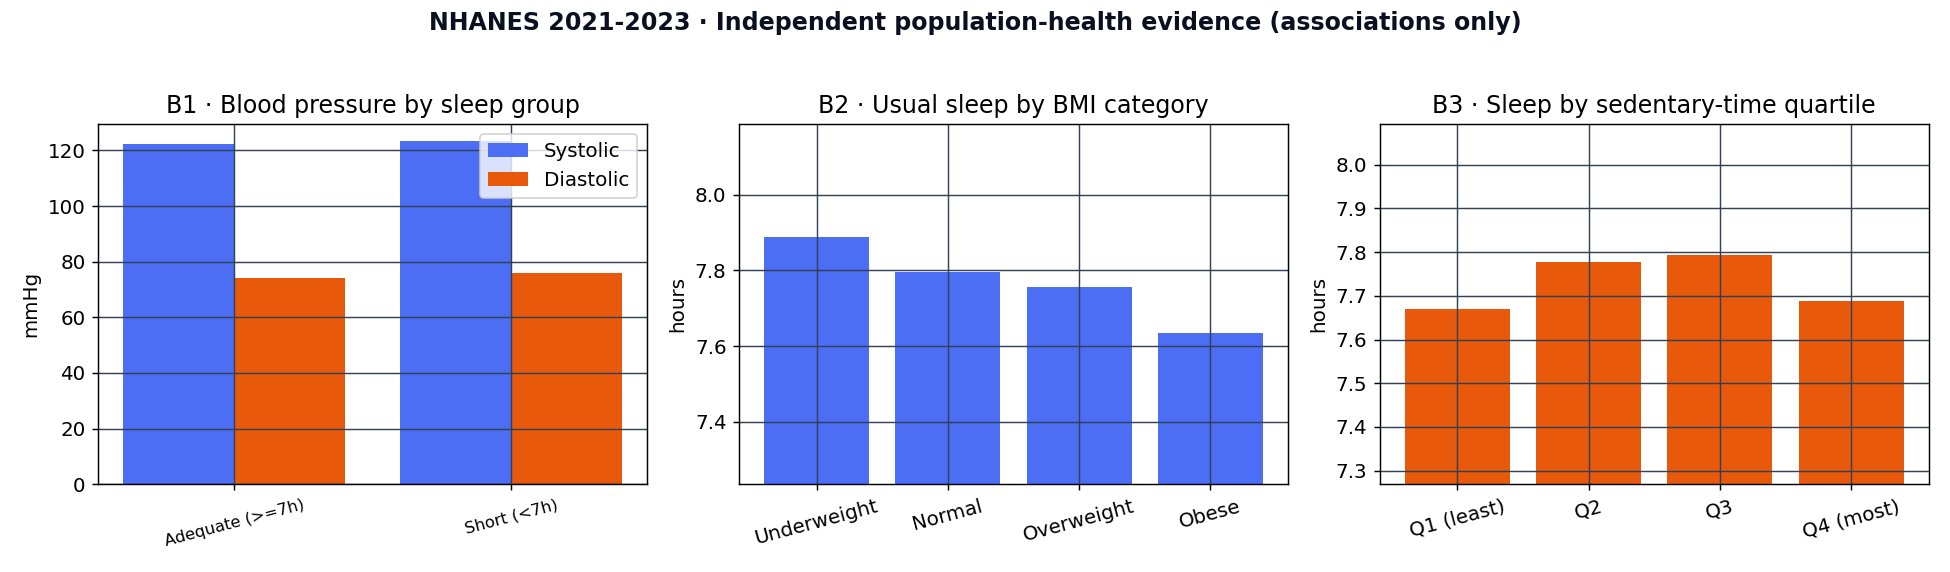

In [1]:
import sys; sys.path.insert(0, 'scripts')
from build_nhanes_evidence import build as build_nhanes
nhanes = build_nhanes()
print(open('outputs/tables/nhanes_summary.json').read()[:0] or '')  # side-effect: writes tables
b1 = nhanes['B1_sleep_blood_pressure']; bmi = nhanes['B2_sleep_by_bmi']
print(f"Adults: {nhanes['analytic_adults']:,}")
print('diastolic (short-adequate):', b1['diastolic_diff_short_minus_adequate'], 'mmHg')
print('Spearman BMI vs sleep:', bmi['spearman_bmi_vs_sleep'])

**Layer B takeaway.** Short sleepers show modestly higher blood pressure and usual sleep
edges down as BMI rises — directions consistent with the wider sleep-health literature,
observed here independently of the Night Signals survey.

## Layer C — PhysioNet Sleep-Accel (objective physiology)

Apple Watch heart rate summarised over polysomnography-scored sleep stages for 31 subjects.
This characterises objective sleep physiology; it is **not** used to claim doomscrolling
changes heart rate.

PhysioNet Sleep-Accel: 31 subjects, 26,417 scored epochs

C1  Mean heart rate by sleep stage (bpm):
    Wake         67.8  (HR variability 8.00)
    N1 (light)   66.5  (HR variability 7.66)
    N2           63.8  (HR variability 4.26)
    N3 (deep)    66.0  (HR variability 2.66)
    REM          66.7  (HR variability 5.10)

    Wake - deep(N3) heart-rate drop: 1.8 bpm
    Median awakenings after onset: 12


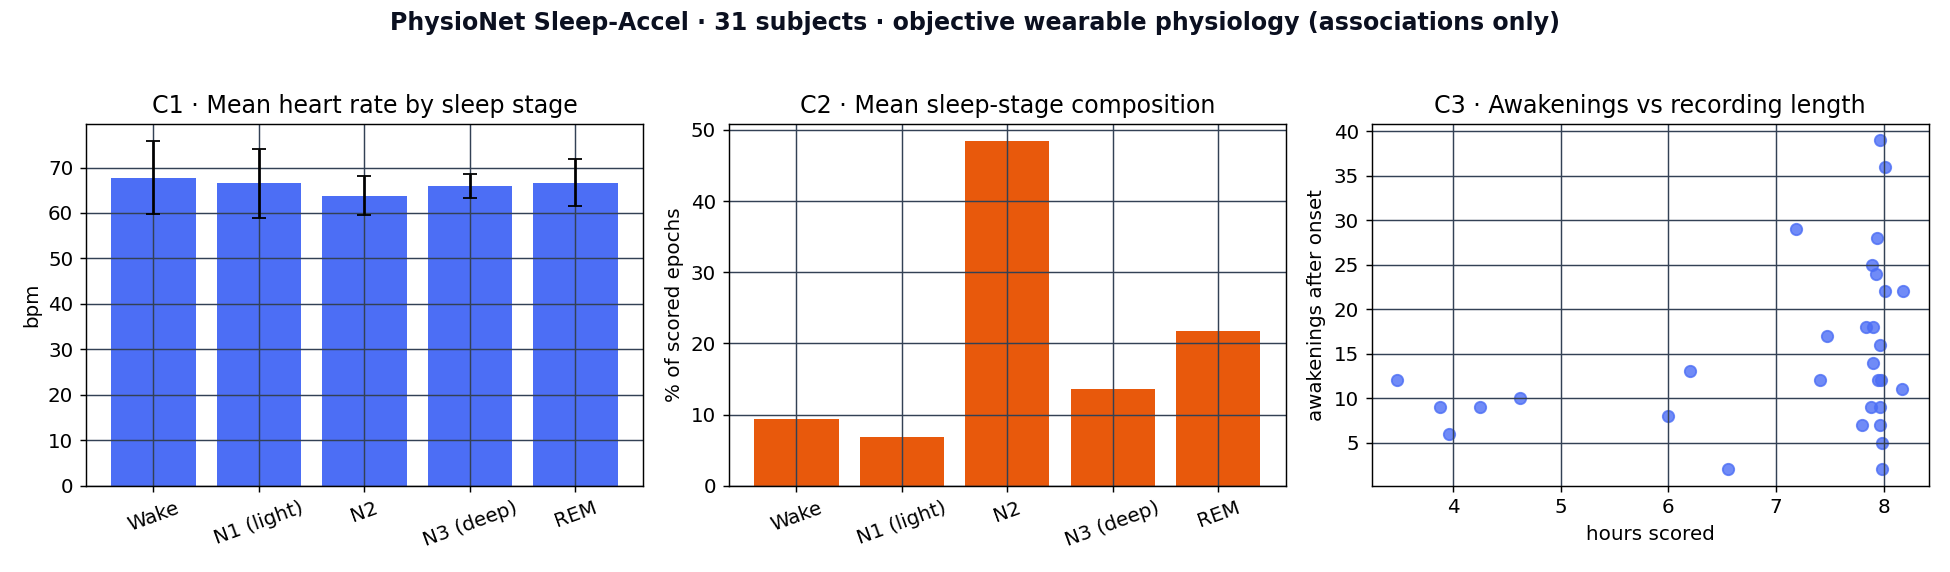

In [2]:
from build_physionet_evidence import build as build_physionet
physio = build_physionet()
for r in physio['hr_by_stage']:
    print(f"{r['stage_name']:<12} {r['mean_hr']:.1f} bpm  (variability {r['mean_hr_variability']:.2f})")
print('wake - deep HR drop:', physio['wake_minus_deep_hr'], 'bpm')

**Layer C takeaway.** Heart rate and its short-term variability fall from wake into deep
(N3) sleep and the stage composition matches normal adult architecture — an objective
physiological picture that complements the survey's self-reported sleep.

## Boundary

NHANES and PhysioNet describe different people, devices, and variable definitions from the
primary survey. They are independent **evidence layers**, not a combined training table, and
do not by themselves externally validate the poor-sleep classifier (see `EXTERNAL_VALIDATION.md`).